# Homework 4: Two-Stream SW Radiative Transfer and the Aerosol Direct Radiative Effect

**Name:** Claire Liu   
**Date:** 6/8/26

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
##reading data files
aer = pd.read_csv('data/aerosol_properties.csv')
oce = pd.read_csv('data/ocean_reflectance.csv')
fo_raw = pd.read_csv('data/Fo.csv')
fo_raw.columns = fo_raw.columns.str.strip()

In [6]:
# SPECTRAL GRID
lam  = np.arange(0.4, 4.01, 0.1)   # wavelength in µm
dlam = 0.1

In [7]:
def interp_aer(col):
    return np.interp(lam, aer['lambda (mu)'], aer[col])

dust_Be    = interp_aer('dust Be')
dust_g     = interp_aer('dust g')
dust_omega = interp_aer('dust omega')

poll_Be    = interp_aer('pollution Be')
poll_g     = interp_aer('pollution g')
poll_omega = interp_aer('pollution omega')

In [8]:
# Spectral AOD: τ_a(λ) = τ_a,0.55 × Be(λ)
tau_a0     = 1.0
dust_tau_a = tau_a0 * dust_Be
poll_tau_a = tau_a0 * poll_Be

In [9]:
rs = np.interp(lam, oce['lambda (mu)'], oce['reflectance'])
rs = np.where(lam > oce['lambda (mu)'].max(), 0.0, rs)

In [10]:
#Rayleigh scattering
tau_R0  = 0.1
tau_R   = tau_R0 * (0.55 / lam)**4
omega_R = np.ones_like(lam)
g_R     = np.zeros_like(lam)

## 5.1 Model constructions

**Two-stream diffusion exponent** (Petty Eq. 13.25):
$$\Gamma = 2\sqrt{1-\tilde{\omega}}\sqrt{1-\tilde{\omega}g}$$

**Semi-infinite reflectance** (Petty Eq. 13.45):
$$r_\infty = \frac{\sqrt{1-\tilde{\omega}g} - \sqrt{1-\tilde{\omega}}}{\sqrt{1-\tilde{\omega}g} + \sqrt{1-\tilde{\omega}}}$$

**Layer reflectance** (Petty Eq. 13.65):
$$r = \frac{r_\infty\left[e^{\Gamma\tau^*} - e^{-\Gamma\tau^*}\right]}{e^{\Gamma\tau^*} - r_\infty^2 e^{-\Gamma\tau^*}}$$

**Layer transmittance** (Petty Eq. 13.66):
$$t = \frac{1 - r_\infty^2}{e^{\Gamma\tau^*} - r_\infty^2 e^{-\Gamma\tau^*}}$$

### Multi-layer combination (adding method)

For two layers with $(r_1, t_1)$ on top and $(r_2, t_2)$ below:

$$r_{12} = r_1 + \frac{t_1^2 \, r_2}{1 - r_1 r_2}$$

$$t_{12} = \frac{t_1 \, t_2}{1 - r_1 r_2}$$

The $1/(1-r_1 r_2)$ term sums the geometric series of multiple reflections between layers.

### Downward flux at surface

Accounting for multiple reflections between the atmosphere and surface:

$$F^\downarrow_\text{sfc} = F_0 \cdot \frac{t_\text{atm}}{1 - r_\text{atm} \cdot r_s}$$

### Aerosol spectral optical depth

$$\tau_a(\lambda) = \tau_{a,0.55} \cdot B_e(\lambda)$$

where $B_e$ is the extinction coefficient normalized to 1 at $\lambda = 0.55\ \mu$m.

### Rayleigh optical depth

$$\tau_R(\lambda) = \tau_{R,0.55} \left(\frac{0.55}{\lambda}\right)^4$$

In [11]:
def two_stream_layer(tau_star, omega, g):
    omega = np.clip(omega, 0, 1 - 1e-10)
    Gamma = 2.0 * np.sqrt(1.0 - omega) * np.sqrt(1.0 - omega * g)
    r_inf = (np.sqrt(1.0 - omega*g) - np.sqrt(1.0 - omega)) / \
            (np.sqrt(1.0 - omega*g) + np.sqrt(1.0 - omega))
    Gtau  = np.clip(Gamma * tau_star, 0, 500)
    epos, eneg = np.exp(Gtau), np.exp(-Gtau)
    denom = epos - r_inf**2 * eneg
    r = r_inf * (epos - eneg) / denom
    t = (1.0 - r_inf**2) / denom
    return r, t

def add_layers(r1, t1, r2, t2):
    denom = 1.0 - r1 * r2
    return r1 + t1**2 * r2 / denom, t1 * t2 / denom

def two_stream_model(tau_aer, omega_aer, g_aer, tau_ray, rs):
    r_aer, t_aer = two_stream_layer(tau_aer, omega_aer, g_aer)
    r_ray, t_ray = two_stream_layer(tau_ray, omega_R,   g_R)
    r_atm, t_atm = add_layers(r_aer, t_aer, r_ray, t_ray)
    r_toa, _     = add_layers(r_atm, t_atm, rs, np.zeros_like(rs))
    t_sfc        = t_atm / (1.0 - r_atm * rs)
    return r_toa, t_sfc, r_atm, t_atm


## 5.2 Verifications

For the first test, I tried the limiting case where ω̃=0(no scattering) and g=0. This should give reflectance that's close to 0 and t=exp(-τ*2)(assuming u bar =0.5, given by equation 13.68 in Petty).

In [14]:
# TEST 1: Non-scattering (ω̃ → 0)
# Expected: r → 0, t → exp(-τ*)
test_tau   = np.array([0.1, 0.5, 1.0, 2.0])
test_omega = np.full_like(test_tau, 1e-10)
test_g     = np.zeros_like(test_tau)

r_test, t_test = two_stream_layer(test_tau, test_omega, test_g)

print('=== Test 1: Non-scattering (ω̃ → 0) ===')
print(f"{'τ*':>6}  {'r (model)':>12}  {'t (model)':>12}  {'exp(-2τ)':>12}")
for i, tau in enumerate(test_tau):
    print(f"{tau:>6.1f}  {r_test[i]:>12.6f}  {t_test[i]:>12.6f}  {np.exp(-tau*2):>12.6f}") ##assuming u bar =0.5

=== Test 1: Non-scattering (ω̃ → 0) ===
    τ*     r (model)     t (model)      exp(-2τ)
   0.1      0.000000      0.818731      0.818731
   0.5      0.000000      0.367879      0.367879
   1.0      0.000000      0.135335      0.135335
   2.0      0.000000      0.018316      0.018316


For the second test, I used ω̃ = 1 and rs = 0 which represents the case where all the light was scattered and the surface is fully absorbant, so light can only either be reflected back up or tansmitted down, expecting r+t=1

In [16]:
# TEST 2: ω̃ = 1, rs = 0
# Expected: r + t = 1
test_tau2   = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
test_omega2 = np.ones_like(test_tau2)
test_g2     = np.full_like(test_tau2, 0.7)

r_test2, t_test2 = two_stream_layer(test_tau2, test_omega2, test_g2)

print('\n=== Test 2: ω̃ = 1, rs = 0 ===')
print(f"{'τ*':>6}  {'r':>10}  {'t':>10}  {'r+t':>10}  {'error':>10}")
for i, tau in enumerate(test_tau2):
    print(f"{tau:>6.1f}  {r_test2[i]:>10.6f}  {t_test2[i]:>10.6f}  {r_test2[i]+t_test2[i]:>10.6f}  {r_test2[i]+t_test2[i]-1:>10.2e}")


=== Test 2: ω̃ = 1, rs = 0 ===
    τ*           r           t         r+t       error
   0.1    0.029126    0.970874    1.000000   -2.04e-11
   0.5    0.130435    0.869565    1.000000   -9.94e-11
   1.0    0.230769    0.769231    1.000000   -2.00e-10
   2.0    0.375000    0.625000    1.000000   -4.00e-10
   5.0    0.600000    0.400000    1.000000   -1.00e-09


## 5.3 

In [24]:
tau_zero  = np.zeros_like(lam)
omega_one = np.full_like(lam, 0.9999)
g_zero    = np.zeros_like(lam)

r_p, t_p, _, _ = two_stream_model(tau_zero,   omega_one,  g_zero,    tau_R, rs)
r_d, t_d, _, _ = two_stream_model(dust_tau_a, dust_omega, dust_g,    tau_R, rs)
r_po,t_po, _, _= two_stream_model(poll_tau_a, poll_omega, poll_g,    tau_R, rs)


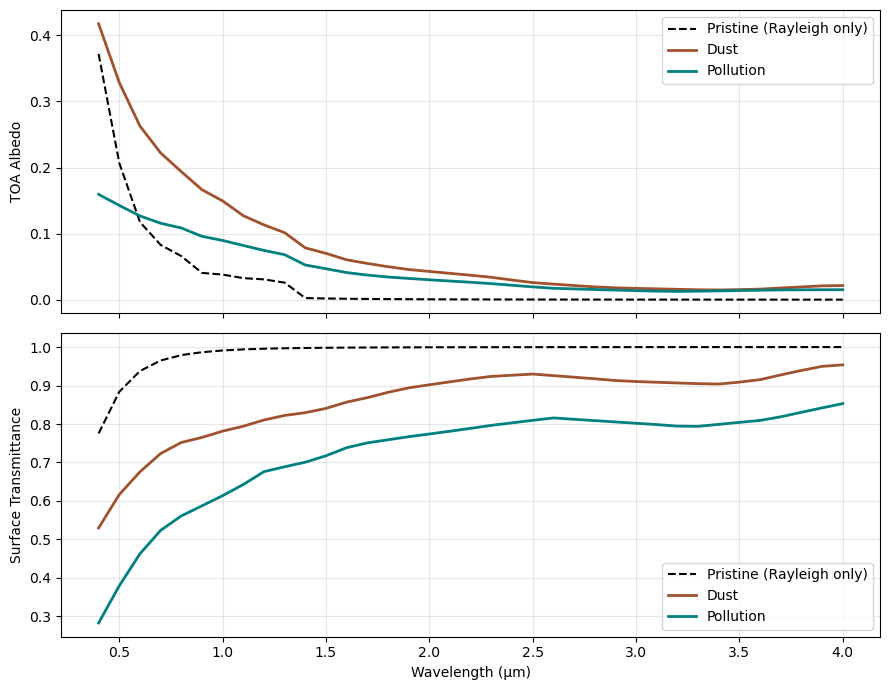

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax = axes[0]
ax.plot(lam, r_p,  'k--', label='Pristine (Rayleigh only)', lw=1.5)
ax.plot(lam, r_d,  color='sienna', label='Dust', lw=2)
ax.plot(lam, r_po, color='teal',   label='Pollution', lw=2)
ax.set_ylabel('TOA Albedo')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(lam, t_p,  'k--', label='Pristine (Rayleigh only)', lw=1.5)
ax.plot(lam, t_d,  color='sienna', label='Dust', lw=2)
ax.plot(lam, t_po, color='teal',   label='Pollution', lw=2)
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('Surface Transmittance')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/spectral_r_t.png', dpi=150)
plt.show()

**Dust has both higher TOA albedo and surface transmittance compared to pollution. This is consistent with the values of omega. Based on the table, dust has significantly greater omega compared to pollution at all wavelength. This means that it's more likely to scatter both upward and downward.**

# 6 Part II: Shortwave Fluxes and the DRE

## 6.1 Model Construction

In [27]:
fo_lam_nm = fo_raw['lambda (nm)'].values
fo_flux   = fo_raw['TOA Flux (W/m2/nm)'].values

Fo_band = np.zeros(len(lam))
for i, lc in enumerate(lam):
    lo, hi = (lc - dlam/2)*1000, (lc + dlam/2)*1000
    mask = (fo_lam_nm >= lo) & (fo_lam_nm < hi)
    if mask.sum() > 1:
        Fo_band[i] = np.trapz(fo_flux[mask], fo_lam_nm[mask])
    elif mask.sum() == 1:
        Fo_band[i] = fo_flux[mask][0] * (hi - lo)

In [28]:
def compute_fluxes(r_toa, t_sfc, rs, Fo_band):
    F_down_sfc = t_sfc * Fo_band
    return {
        'F_up_toa_spec'  : r_toa * Fo_band,
        'F_down_sfc_spec': F_down_sfc,
        'F_up_toa'       : (r_toa * Fo_band).sum(),
        'F_down_sfc'     : F_down_sfc.sum(),
        'F_up_sfc'       : (rs * F_down_sfc).sum(),
    }

def compute_DRE(flx_aer, flx_pris, rs):
    DRE_toa = flx_pris['F_up_toa'] - flx_aer['F_up_toa']
    DRE_sfc = np.sum((flx_aer['F_down_sfc_spec'] - flx_pris['F_down_sfc_spec']) * (1 - rs))
    return {'TOA': DRE_toa, 'sfc': DRE_sfc, 'atm': DRE_toa - DRE_sfc}


In [33]:
fp  = compute_fluxes(r_p,  t_p,  rs, Fo_band)
fd  = compute_fluxes(r_d,  t_d,  rs, Fo_band)
fpo = compute_fluxes(r_po, t_po, rs, Fo_band)

dre_dust = compute_DRE(fd,  fp, rs)
dre_poll = compute_DRE(fpo, fp, rs)

print(f"{'':12s}  {'Dust':>10}  {'Pollution':>10}")
for loc in ['TOA', 'sfc', 'atm']:
    print(f"DRE_{loc:4s}      {dre_dust[loc]:>10.2f}  {dre_poll[loc]:>10.2f}")

                    Dust   Pollution
DRE_TOA          -128.87        9.63
DRE_sfc          -255.56     -475.96
DRE_atm           126.69      485.59


## 6.2 Verifications

For verifications, I tried the case with no aerosol (tau = 0). This should give 0 for all the DRE values.

In [32]:
tau_zero  = np.zeros_like(lam)
omega_any = np.full_like(lam, 0.9999)  # doesn't matter when τ=0
g_any     = np.zeros_like(lam)

r_test, t_test, _, _ = two_stream_model(tau_zero, omega_any, g_any, tau_R, rs)
flx_test = compute_fluxes(r_test, t_test, rs, Fo_band)
dre_test  = compute_DRE(flx_test, fp, rs)

print(f"DRE_TOA = {dre_test['TOA']:.6f}  ")
print(f"DRE_sfc = {dre_test['sfc']:.6f}  ")
print(f"DRE_atm = {dre_test['atm']:.6f} ")

DRE_TOA = 0.000000  
DRE_sfc = 0.000000  
DRE_atm = 0.000000 


## 6.3 Questions

a. For dust, the instantaneous DRE at the top of the atmosphere is -128.87 and 9.63 for pollution. The differences are mainly caused by the differences in omega values. Dust has greater omega values which means it scatters more light away. 

b. Since net flux was defined as Fp_up - F_up, negative values indicate cooling and vice versa. So dust has an overall cooling effecs and pollution slightly warms the system. 

c. Both aerosols reduce have negative DRE_sfc values, which means that they cool the surface and stabilize the lower atmosphere, suppressing convection. 

d. 

    rs    Dust DRE_TOA    Poll DRE_TOA
  0.05         -134.77            1.06
  0.10         -112.66           37.36
  0.30          -26.88          184.20
  0.50           53.98          333.91
  0.80          163.58          564.85


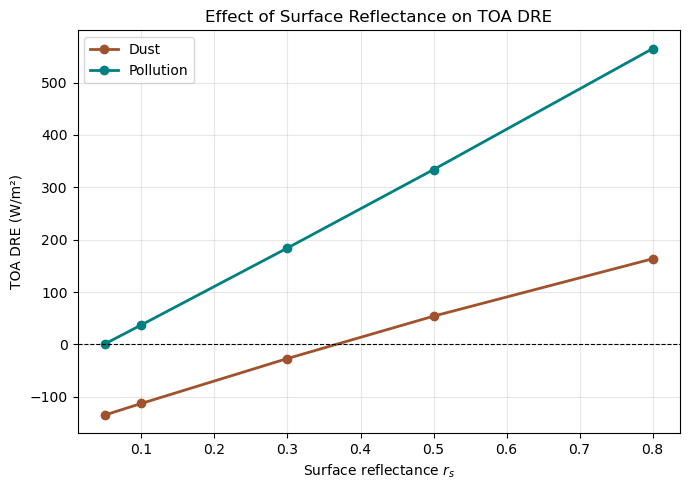

In [35]:
rs_values = [0.05, 0.1, 0.3, 0.5, 0.8]
dre_toa_dust = []
dre_toa_poll = []

for rs_val in rs_values:
    rs_test = np.full_like(lam, rs_val)
    
    # pristine
    r_p, t_p, _, _ = two_stream_model(tau_zero, omega_one, g_zero, tau_R, rs_test)
    fp_test = compute_fluxes(r_p, t_p, rs_test, Fo_band)
    
    # dust
    r_d, t_d, _, _ = two_stream_model(dust_tau_a, dust_omega, dust_g, tau_R, rs_test)
    fd_test = compute_fluxes(r_d, t_d, rs_test, Fo_band)
    
    # pollution
    r_po, t_po, _, _ = two_stream_model(poll_tau_a, poll_omega, poll_g, tau_R, rs_test)
    fpo_test = compute_fluxes(r_po, t_po, rs_test, Fo_band)
    
    dre_toa_dust.append(compute_DRE(fd_test,  fp_test, rs_test)['TOA'])
    dre_toa_poll.append(compute_DRE(fpo_test, fp_test, rs_test)['TOA'])

# print table
print(f"{'rs':>6}  {'Dust DRE_TOA':>14}  {'Poll DRE_TOA':>14}")
for i, rs_val in enumerate(rs_values):
    print(f"{rs_val:>6.2f}  {dre_toa_dust[i]:>14.2f}  {dre_toa_poll[i]:>14.2f}")

# plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rs_values, dre_toa_dust, color='sienna', marker='o', lw=2, label='Dust')
ax.plot(rs_values, dre_toa_poll, color='teal',   marker='o', lw=2, label='Pollution')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Surface reflectance $r_s$')
ax.set_ylabel('TOA DRE (W/m²)')
ax.set_title('Effect of Surface Reflectance on TOA DRE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/DRE_vs_rs.png', dpi=150)
plt.show()

Based on the plot, changes in surface reflectance have a larger impact on pollution than dust, as seen by the steeper slope in DRE_TOA vs rs. As rs increases, more light is reflected upward from the surface into the aerosol layer. Pollution, with its low ω̃, absorbs most of this additional upwelling radiation, strongly amplifying the warming effect. Dust, with its high ω̃, mostly scatters the additional upwelling rather than absorbing it, leading to a weaker response to surface reflectance changes.

e. 

In [36]:
dtau = 0.1

for name, Be, omega, g in [('Dust', dust_Be, dust_omega, dust_g),
                            ('Pollution', poll_Be, poll_omega, poll_g)]:
    # run at τ ± δτ
    r_lo, t_lo, _, _ = two_stream_model((tau_a0 - dtau)*Be, omega, g, tau_R, rs)
    r_hi, t_hi, _, _ = two_stream_model((tau_a0 + dtau)*Be, omega, g, tau_R, rs)
    
    f_lo = compute_fluxes(r_lo, t_lo, rs, Fo_band)
    f_hi = compute_fluxes(r_hi, t_hi, rs, Fo_band)
    
    dre_lo = compute_DRE(f_lo, fp, rs)
    dre_hi = compute_DRE(f_hi, fp, rs)
    
    FE = (dre_hi['TOA'] - dre_lo['TOA']) / (2 * dtau)
    print(f'{name} TOA Forcing Efficiency: {FE:.2f} W/m² per unit τ_a')

Dust TOA Forcing Efficiency: -96.33 W/m² per unit τ_a
Pollution TOA Forcing Efficiency: -5.57 W/m² per unit τ_a


Dust has a larger magnitude forcing efficiency because each unit of AOD scatters more light back to space (high ω̃). Pollution's forcing efficiency is much smaller because most of the energy goes into absorption rather than backscattering, so adding more AOD has less impact on the TOA radiation budget.

# 7 Part III: Student Investigation

Questions: I've read that single scatter albedo retrieved from remote sensing instruments has an uncertainty on the order of 0.01-0.1. So I wonder how sensitive are the TOA DRE estimates for dust and pollution aerosols to this uncertainty, and is the sign of the DRE robust for both species?

Hypothesis: I think that the dust would be more sensitive to changes in single scatter albedo, considering that it's more sensitive to the surface reflectance as well. And I do think the sign of TOA DRE could be fliped based on how it was fliped when surface reflectance changes.

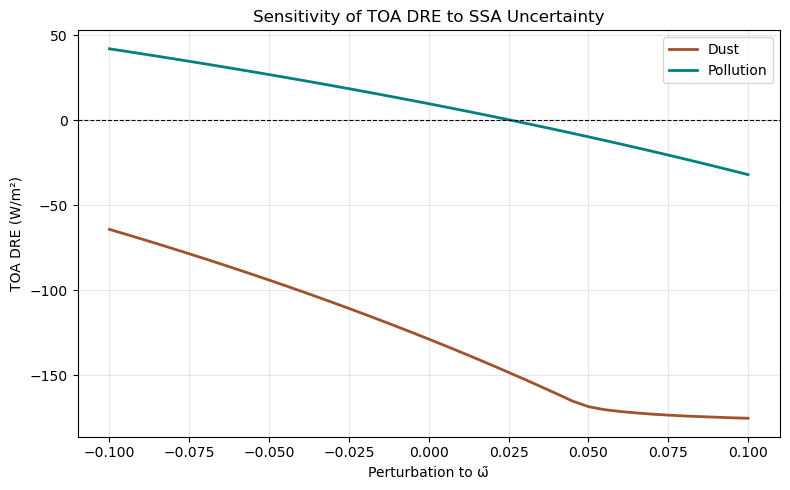

TOA DRE across SSA perturbation range:
                  ω̃ - 0.1      baseline      ω̃ + 0.1         range
Dust                -64.30       -128.87       -175.44       -111.14
Pollution            41.94          9.63        -32.09        -74.03


In [39]:
omega_perturbations = np.linspace(-0.1, 0.1, 41)
dre_toa_dust_ssa = []
dre_toa_poll_ssa = []

for d_omega in omega_perturbations:
    omega_dust_pert = np.clip(dust_omega + d_omega, 1e-10, 1 - 1e-10)
    omega_poll_pert = np.clip(poll_omega + d_omega, 1e-10, 1 - 1e-10)

    r_d, t_d, _, _ = two_stream_model(dust_tau_a, omega_dust_pert, dust_g, tau_R, rs)
    r_po, t_po, _, _ = two_stream_model(poll_tau_a, omega_poll_pert, poll_g, tau_R, rs)

    fd  = compute_fluxes(r_d,  t_d,  rs, Fo_band)
    fpo = compute_fluxes(r_po, t_po, rs, Fo_band)

    dre_toa_dust_ssa.append(compute_DRE(fd,  fp, rs)['TOA'])
    dre_toa_poll_ssa.append(compute_DRE(fpo, fp, rs)['TOA'])

dre_toa_dust_ssa = np.array(dre_toa_dust_ssa)
dre_toa_poll_ssa = np.array(dre_toa_poll_ssa)


# PLOT
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(omega_perturbations, dre_toa_dust_ssa, color='sienna', lw=2, label='Dust')
ax.plot(omega_perturbations, dre_toa_poll_ssa, color='teal',   lw=2, label='Pollution')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Perturbation to ω̃')
ax.set_ylabel('TOA DRE (W/m²)')
ax.set_title('Sensitivity of TOA DRE to SSA Uncertainty')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/DRE_ssa_sensitivity.png', dpi=150)
plt.show()

idx_lo = 0   # most negative perturbation
idx_hi = -1  # most positive perturbation
idx_0  = len(omega_perturbations) // 2  # baseline (perturbation = 0)

print('TOA DRE across SSA perturbation range:')
print(f"{'':12s}  {'ω̃ - 0.1':>12}  {'baseline':>12}  {'ω̃ + 0.1':>12}  {'range':>12}")
for name, arr in [('Dust', dre_toa_dust_ssa), ('Pollution', dre_toa_poll_ssa)]:
    lo, base, hi = arr[idx_lo], arr[idx_0], arr[idx_hi]
    print(f"{name:12s}  {lo:>12.2f}  {base:>12.2f}  {hi:>12.2f}  {hi-lo:>12.2f}")

The results partially confirm the hypothesis. For SSA perturbations between −0.1 and +0.05, dust shows a steeper slope and is more sensitive to SSA uncertainty than pollution. However, for perturbations between +0.05 and +0.1, dust's sensitivity decreases and pollution becomes more sensitive. I think this is because dust's baseline ω̃ is already high (~ 0.95), so positive perturbations push it close to the conservative scattering limit (ω̃ = 1) where the marginal effect of increasing ω̃ further diminishes. Pollution, with a lower baseline ω̃ (~ 0.70), remains far from this limit and responds more linearly across the full range.
Regarding sign flipping, dust's TOA DRE remains negative throughout since it's too far from zero to flip. Pollution however crosses zero within a realistic uncertainty range, flipping from warming to cooling. This suggests that for absorbing aerosols like pollution that sit close to the cooling/warming threshold, even moderate SSA uncertainty can change our conclusion about the sign of their climate effect, which has direct implications for how accurately ω̃ needs to be retrieved from remote sensing instruments.

## AI Usage

AI Tool used: Claude

How I used: I used it to generate the majority of the code in the notebook. I went over the textbook section about two stream solutions and put down all the equations that I need to construct the model and let AI provide the code for that.  

What I checked: I did the verifications tests and went over aerosol direct radiative effect/two stream solutions myself to make sure what I'm getting from the code conceptually make sense. 

Something I verified: For the first part, I did went over the code line by line to make sure the equations used were right(for one of the verificaitons, I found the error of not assuming mu bar = 0.5 which gave the wrong results in the first place) and that I understood all the python functions that were used. It took kind of long so I didn't went over as many details for the later part. 
